# [Introduction to Data Science](http://datascience-intro.github.io/1MS041-2025/)    
## 1MS041, 2025 
&copy;2025 Raazesh Sainudiin, Benny Avelin. [Attribution 4.0 International     (CC BY 4.0)](https://creativecommons.org/licenses/by/4.0/)

## Second notebook on Random variables

Lets take a look again at the spam dataset and look at our concepts there

this is about SMS and spam type of question.

In [46]:
from Utils import load_sms
sms_data = load_sms()
sms_data[:2]

[('Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...',
  0),
 ('Ok lar... Joking wif u oni...', 0)]

Let X represents each SMS text (an entry in the list), and let $Y$ represent whether text is spam or not i.e. $Y \in \{0,1\}$. Thus $\mathbb{P}(Y = 1)$ is the probability that we get a spam. The goal is to estimate:
$$
    \mathbb{P}(Y = 1 | \text{"free" or "prize" is in } X) \enspace .
$$
That is, the probability that the SMS is spam given that "free" or "prize" occurs in the SMS. 
Hint: it is good to remove the upper/lower case of words so that we can also find "Free" and "Prize"; this can be done with `text.lower()` if `text` a string.

To do this we can create a new random variable $Z$ which is $1$ if "free" or "prize" appears in $X$.

In [47]:
interesting_words=set(['free','prize'])
TF10 = {True: 1, False: 0}
Z_obs = [TF10[not interesting_words.isdisjoint([word.lower() for word in line[0].split(' ')])] for line in sms_data]

In [48]:
Z_obs[:10]

[0, 0, 1, 0, 0, 0, 0, 0, 1, 1]

In [49]:
Y_obs = [y for x,y in sms_data]
Y_obs[:10]

[0, 0, 1, 0, 0, 1, 0, 0, 1, 1]

In [50]:
import numpy as np
def F_X_12(x):
    TF10 = {True: 1, False: 0}
    return np.mean([TF10[(y <= x[0]) and (z <= x[1])] for y,z in zip (Y_obs,Z_obs)])

In [51]:
F_X_12([1,0])

np.float64(0.9551328068916008)

This is the JDF for this problem

In [52]:
print("\tz <= 0 \t\tz <= 1")
for x1 in range(0,2):
    print("y <= %d \t" % x1,end='')
    for x2 in range(0,2):
        print("%.2f" % (F_X_12((x1,x2))),end='\t\t')
    print('\n')

	z <= 0 		z <= 1
y <= 0 	0.86		0.87		

y <= 1 	0.96		1.00		



In [53]:
F_X_12((1,0))

np.float64(0.9551328068916008)

In [54]:
F_X_12((0,0)) == F_X_12((0,1))*F_X_12((1,0))

np.False_

In [55]:
F_X_12((0,1))*F_X_12((1,0))

np.float64(0.8270846721557743)

In [56]:
# Are they indepdentent? If so, then the JDF is just the product of the 
# DFs for Y and Z, but
0.865936826992103*0.955132806891601

0.827084672155774

Which is not 0.858, so they are not independent. So lets try to estimate the probability that $Y=1$ given that $Z = 1$. Lets again do that by filtering

In [57]:
np.mean([y for z,y in zip(Z_obs,Y_obs) if z == 1])

np.float64(0.812)

Compare that with the marginal probability of $Y = 1$, which is according to our JDF 1-0.866 = 0.134

In [58]:
# Or we can just compute it directly
np.mean(Y_obs)

np.float64(0.13406317300789664)

What we see from this is that knowing that the words "free" or "prize" appeared in the sms text, we are much more certain that it is a spam. We also see that looking directly at the JDF this can be hard to see, although it is equivalent.

In [59]:
x = np.random.normal(size=100)

In [60]:
np.mean(x)

np.float64(-0.10688706982360001)

In [61]:
g = lambda x: x**2

In [62]:
mean = np.mean(x)
y = x-mean
np.mean(y**4)

np.float64(2.3444807145777604)

## Moments etc

In [63]:
import numpy as np
x = np.random.normal(size=100)

In [64]:
x

array([ 2.03900803, -0.67587852,  0.00363898,  1.48755735,  1.27624262,
       -0.97146795, -1.32534643, -0.15353067, -1.2011837 ,  1.9779114 ,
        0.27962003,  0.63065187, -0.04794721, -0.41772394,  0.35362714,
       -2.20225861,  0.74513293, -1.81739861,  0.46779265,  1.94253016,
        0.74984121, -0.30075857, -0.45511335,  0.16002752, -1.09125792,
        1.52755048,  0.26289053,  0.85380637,  0.03059181, -0.28731227,
       -0.09422335,  1.17648864,  0.30722944,  1.10431337,  1.01536079,
       -2.9675599 ,  1.45900822, -0.98899411,  0.52895315,  0.64346263,
       -0.41548881,  0.26448785, -0.32535637,  0.66096849, -1.20356507,
        0.33540557, -0.48071156,  0.91574273, -0.7250085 ,  2.22184692,
       -0.63934899, -0.63620445,  0.36352419, -0.63022996,  1.01573185,
       -0.47131133,  0.16284254, -1.23268294,  0.30963158,  0.27128266,
       -0.7011477 , -1.74677315, -0.80212872, -0.79996316,  0.71113301,
       -1.27384571, -0.03563145, -1.25020016,  0.85957022,  1.25

## Sample mean

In [65]:
np.mean(x)

np.float64(-0.02930082176606755)

## Sample variance

In [66]:
np.var(x)

np.float64(1.1090269129125232)

Or by doing it yourself

In [67]:
mu = np.mean(x)
np.mean(np.power(x-mu,2))

np.float64(1.1090269129125232)

Higher moments, we can use `scipy`

In [68]:
from scipy.stats import skew, kurtosis

In [69]:
skew(x)

np.float64(0.05150112851191636)

In [70]:
kurtosis(x,fisher=False)

np.float64(2.781393185709832)

## Moments and tail behavior

In [71]:
def standardize(data):
    mean = np.mean(data)
    std = np.sqrt(np.var(data))
    return (data-mean)/std

(-3.0, 5.0)

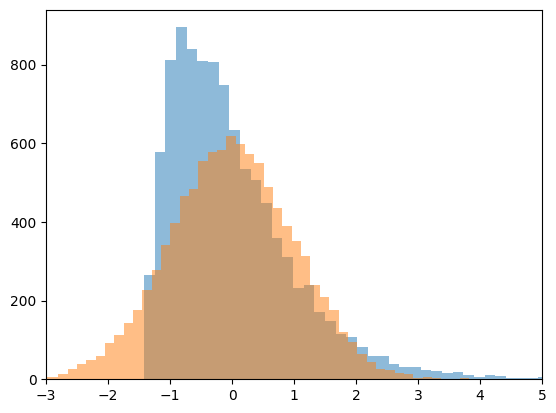

In [72]:
import numpy as np
chi2 = np.random.chisquare(4,size=10000)
normal = np.random.normal(size=10000)
import matplotlib.pyplot as plt
_=plt.hist(standardize(chi2),bins=50,alpha=0.5)
_=plt.hist(standardize(normal),bins=50,alpha=0.5)
plt.xlim(-3,5)

In [73]:
from scipy.stats import skew, kurtosis
def print_basic_stats(data):
    print("mean: %.2f\tstd: %.2f\tskew: %.2f\tkurtosis: %.2f" % (np.mean(data),np.std(data),skew(data),kurtosis(data,fisher=False)))

In [74]:
print_basic_stats(standardize(normal))

mean: 0.00	std: 1.00	skew: 0.00	kurtosis: 2.98


In [75]:
print_basic_stats(standardize(chi2))

mean: -0.00	std: 1.00	skew: 1.43	kurtosis: 6.13


In [76]:
print_basic_stats(standardize(np.sqrt(chi2)))

mean: 0.00	std: 1.00	skew: 0.40	kurtosis: 3.10


In [77]:
np.mean(np.power(standardize(chi2),3)) # Skewness

np.float64(1.4275993839532368)

In [78]:
np.mean(np.power(standardize(chi2),4)) # kurtosis

np.float64(6.134672436937701)

## Transformations of random variables

Consider a Binomial random variable

In [79]:
n = 10
p = 0.5
x = np.random.binomial(n,p,size=1000)

Lets plot the empirical density

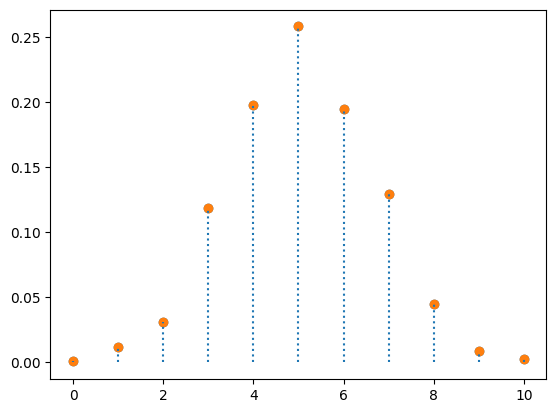

In [80]:
from Utils import makeEMF,makeEDF,plotEDF,plotEMF
plotEMF(makeEMF(x))

If we had the function $g(x) = \sin(x/3)$

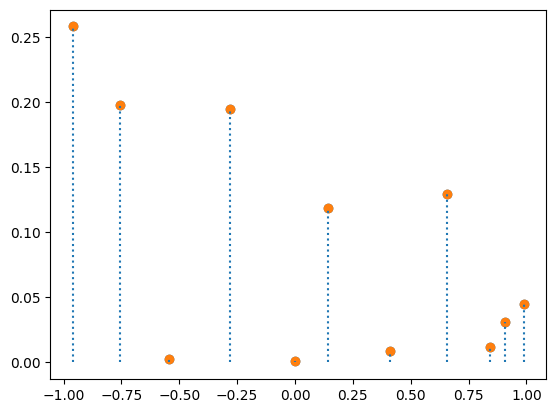

In [81]:
plotEMF(makeEMF(np.sin(x)))

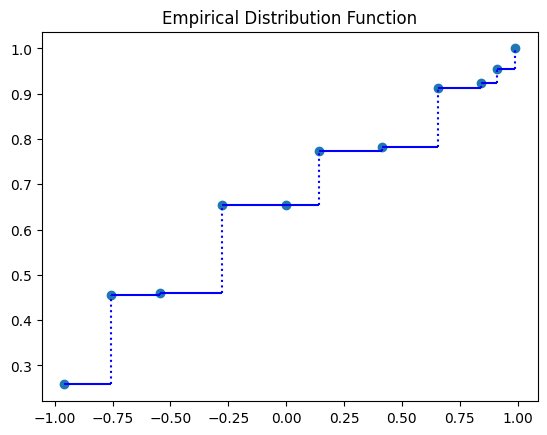

In [82]:
plotEDF(makeEDF(np.sin(x)))

Can we compute this thing?
What is $\sin^{[-1]}$?

Since $X$ is discrete, we can check what $\mathbb{Y}$ is, since $\mathbb{X}=\{0,1,\ldots,10\}$.

In [83]:
Y_space = np.sort(np.sin(np.arange(0,11)))
sin_inv = dict(zip(np.sin(np.arange(0,11)),np.arange(0,11)))

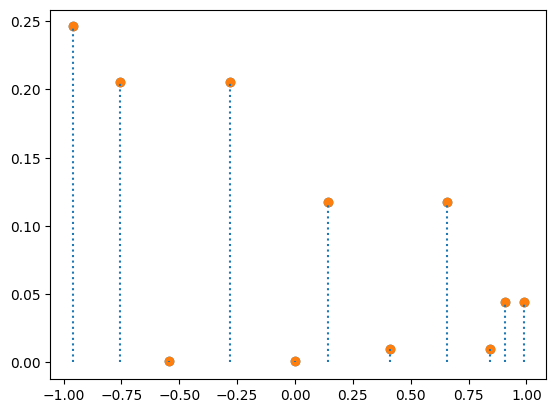

In [84]:
from scipy.special import binom as binomial
plotEMF([(y,binomial(n,sin_inv[y])*(p**sin_inv[y])*((1-p)**(n-sin_inv[y]))) for y in Y_space])

In [85]:
plotEDF(emfToEdf([(y,binomial(n,sin_inv[y])*(p**sin_inv[y])*((1-p)**(n-sin_inv[y]))) for y in Y_space]))

NameError: name 'emfToEdf' is not defined